# Sleep, Mobile Usage & Stress Level Prediction

##  Project Overview

This project analyzes the relationship between **smartphone usage, sleep patterns, and stress levels** using machine learning techniques.

With increasing digital device usage, lifestyle habits such as screen time, sleep quality, caffeine intake, and physical activity play a significant role in influencing mental health.

The goal of this project is to **build a machine learning model capable of predicting stress levels based on lifestyle behaviors**.

## Objectives

The main objectives of this project are:   
     
✔ Analyze the relationship between smartphone usage and stress levels  
✔ Perform Exploratory Data Analysis (EDA) to understand patterns in the data
✔ Apply data preprocessing techniques   
✔ Train multiple machine learning models  
✔ Evaluate models using appropriate performance metrics  
✔ Deploy the final model as an interactive web application  

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("C://Users/lenovo//Downloads//sleep_mobile_stress_dataset_15000.csv")

In [ ]:
#data Cleaning

In [3]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [4]:
df.shape

(15000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [8]:
df.iloc[:,1:].describe()

,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


## Exploratory Data Analysis
Age Distribution

<Axes: xlabel='age', ylabel='Count'>

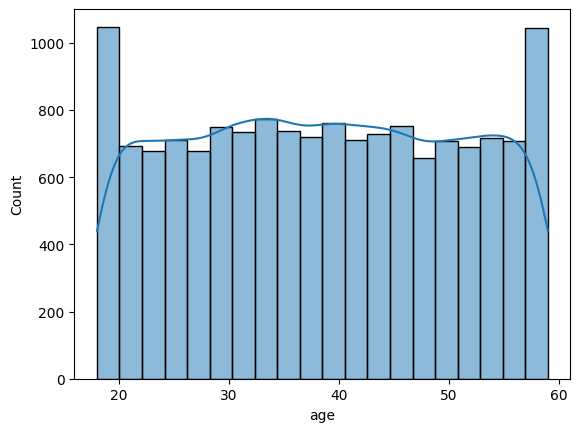

In [11]:
sns.histplot(df["age"],bins=20,kde=True)

Inference

The histogram of the age variable shows that the dataset contains individuals aged approximately between 18 and 60 years. The distribution appears relatively uniform, indicating that participants are evenly distributed across different age groups. The KDE curve suggests no significant skewness or dominant peak, meaning that the dataset does not heavily favor a particular age category. This balanced distribution is beneficial for analysis and machine learning models as it reduces age-related bias.

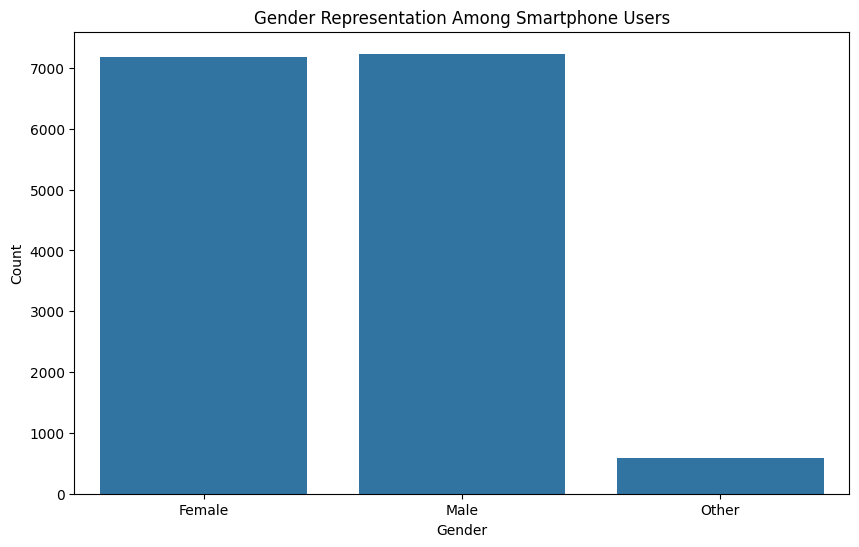

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=df)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Representation Among Smartphone Users")
plt.show()

In [15]:
df["gender"].value_counts()

gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

The gender distribution shows that the dataset contains 7,234 male participants (48.23%), 7,181 female participants (47.87%), and 585 individuals categorized as other (3.9%). The nearly equal representation of male and female participants indicates that the dataset is well balanced in terms of gender. This balance helps reduce gender bias in statistical analysis and machine learning models. Although the “Other” category has a smaller representation, it still contributes to gender diversity in the dataset

In [17]:
#

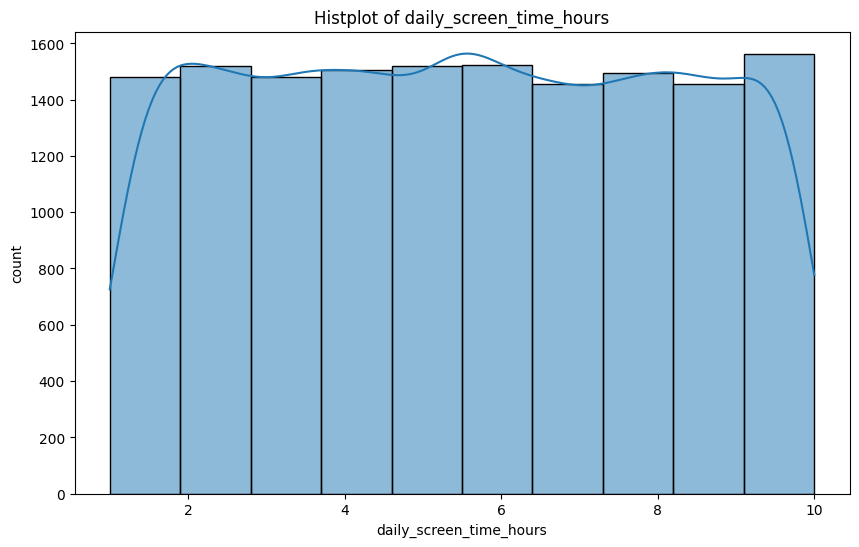

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['daily_screen_time_hours'], bins=10, kde=True)
plt.title("Histplot of daily_screen_time_hours")
plt.xlabel("daily_screen_time_hours")
plt.ylabel("count")
plt.show()

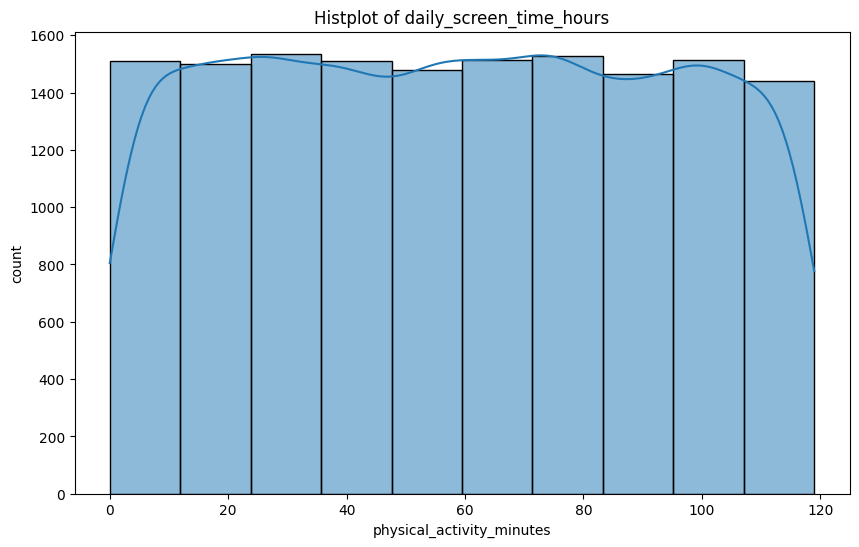

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df['physical_activity_minutes'], bins=10, kde=True)
plt.title("Histplot of daily_screen_time_hours")
plt.xlabel("physical_activity_minutes")
plt.ylabel("count")
plt.show()

In [20]:
#Bivariate analysis

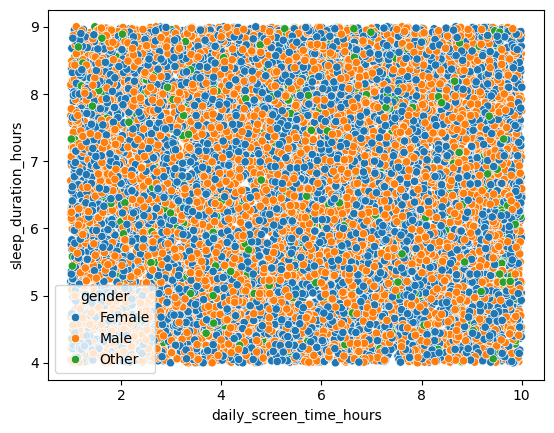

In [21]:
sns.scatterplot(x="daily_screen_time_hours", y="sleep_duration_hours", data=df,hue="gender")
plt.show()

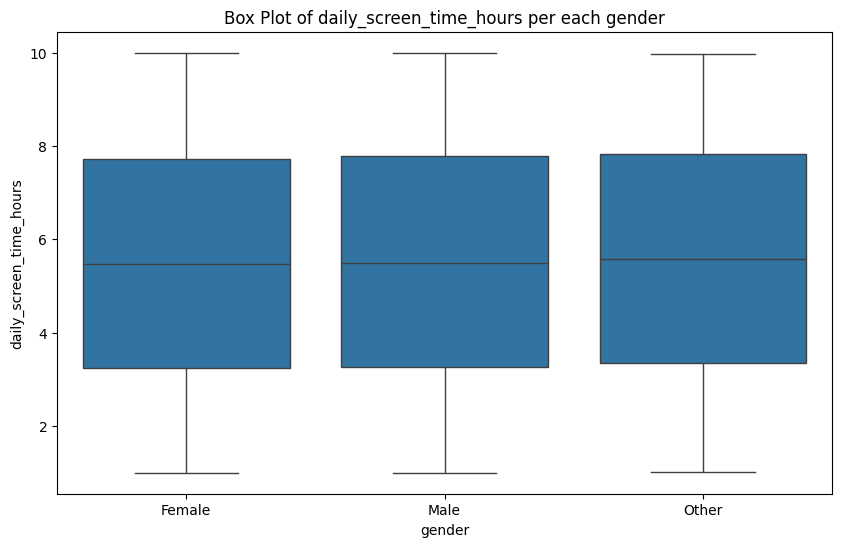

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x="gender",y="daily_screen_time_hours",data=df)
plt.title("Box Plot of daily_screen_time_hours per each gender")
plt.xlabel("gender")
plt.ylabel("daily_screen_time_hours")
plt.show()

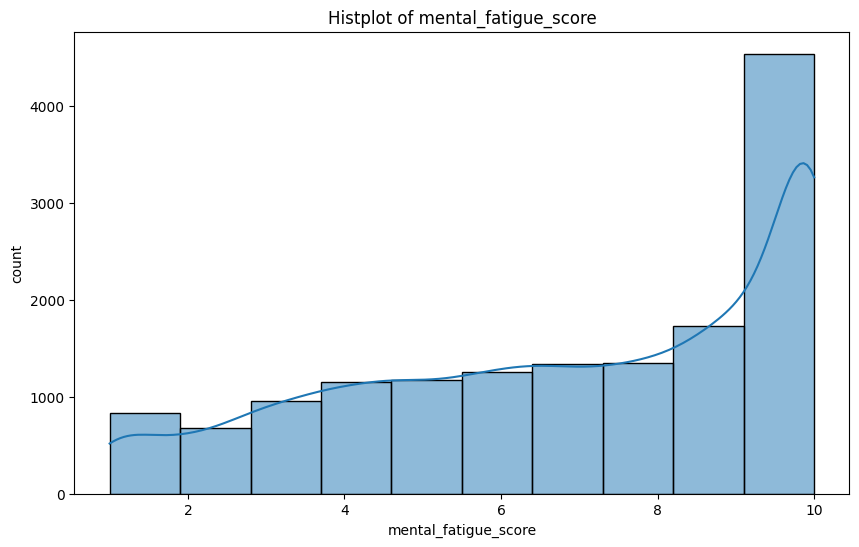

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(df['mental_fatigue_score'], bins=10, kde=True)
plt.title("Histplot of mental_fatigue_score")
plt.xlabel("mental_fatigue_score")
plt.ylabel("count")
plt.show()

In [24]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

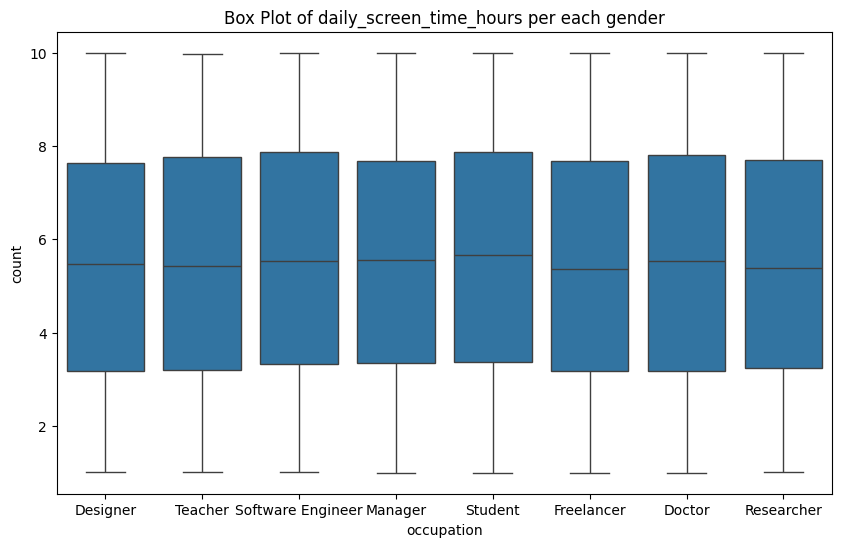

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(x="occupation",y="daily_screen_time_hours",data=df)
plt.title("Box Plot of daily_screen_time_hours per each gender")
plt.xlabel("occupation")
plt.ylabel("count")
plt.show()

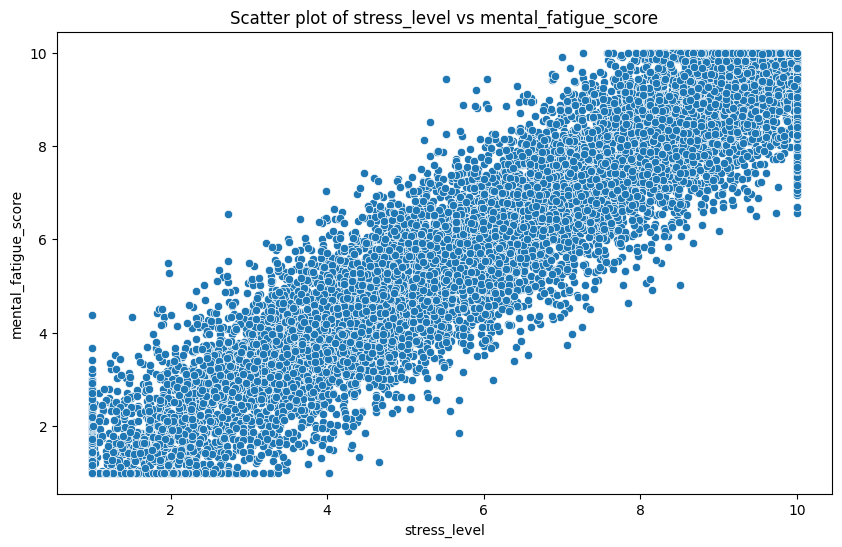

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="stress_level",y="mental_fatigue_score",data=df)
plt.title("Scatter plot of stress_level vs mental_fatigue_score")
plt.xlabel("stress_level")
plt.ylabel("mental_fatigue_score")
plt.show()

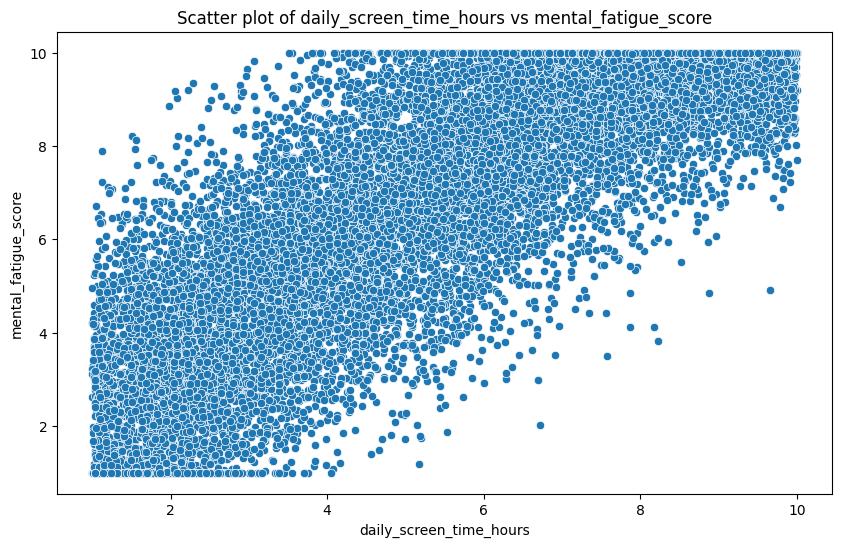

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="daily_screen_time_hours",y="mental_fatigue_score",data=df)
plt.title("Scatter plot of daily_screen_time_hours vs mental_fatigue_score")
plt.xlabel("daily_screen_time_hours")
plt.ylabel("mental_fatigue_score")
plt.show()

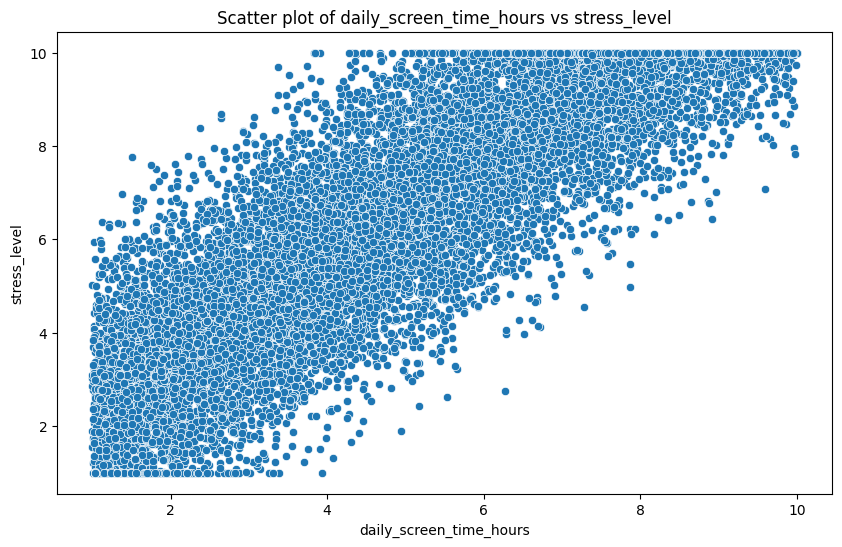

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="daily_screen_time_hours",y="stress_level",data=df)
plt.title("Scatter plot of daily_screen_time_hours vs stress_level")
plt.xlabel("daily_screen_time_hours")
plt.ylabel("stress_level")
plt.show()

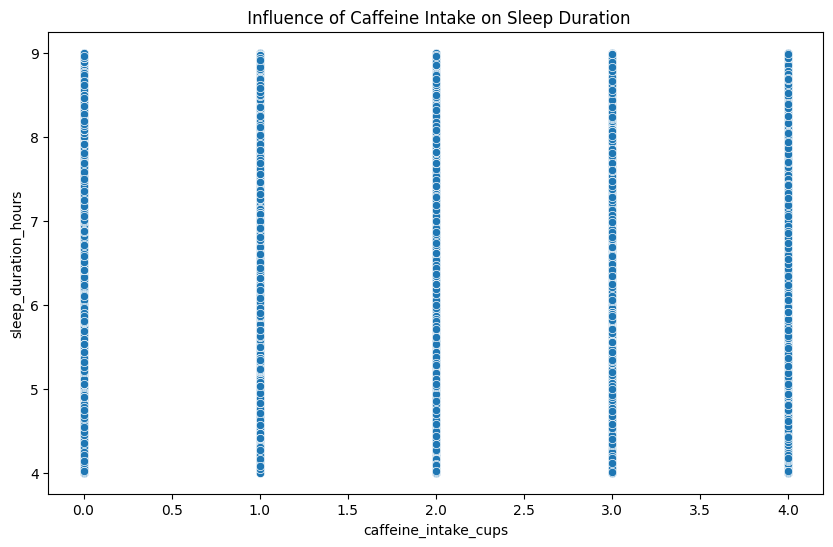

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='caffeine_intake_cups', y='sleep_duration_hours', data=df)
plt.title(' Influence of Caffeine Intake on Sleep Duration')
plt.show()

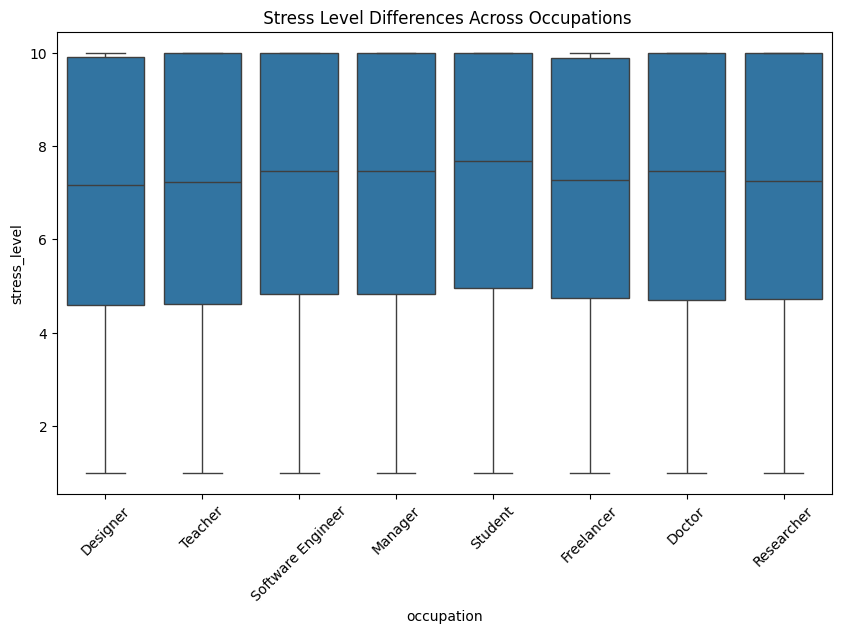

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='occupation', y='stress_level', data=df)
plt.title(' Stress Level Differences Across Occupations')
plt.xticks(rotation=45)
plt.show()

### Correlation Analysis

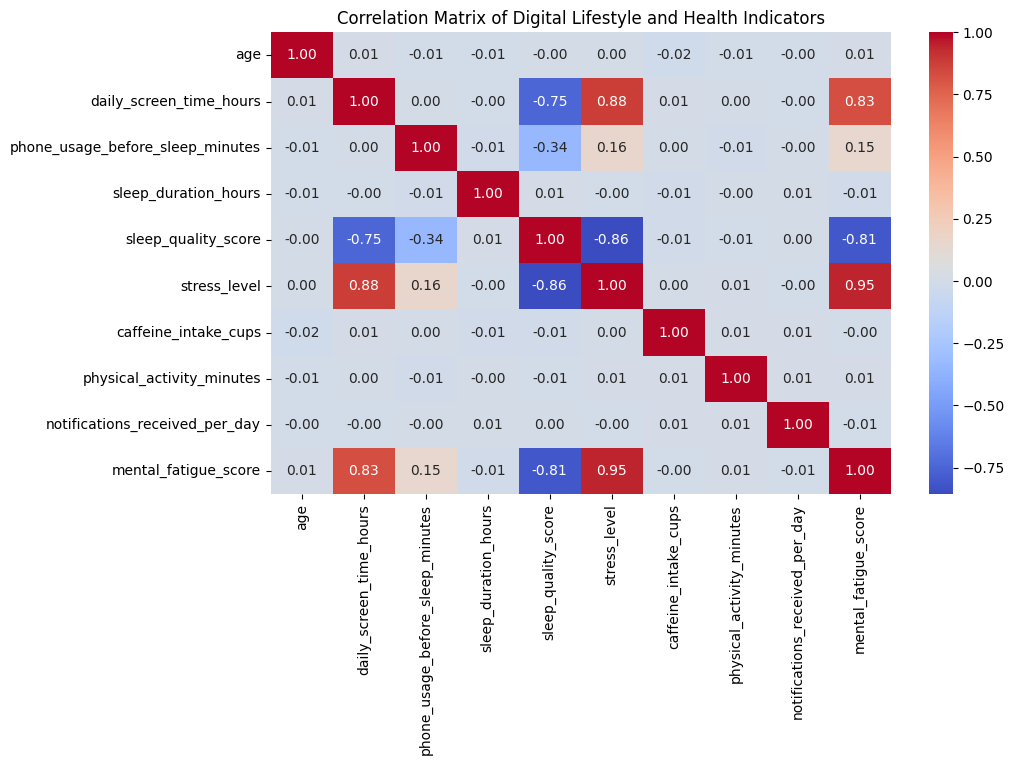

In [31]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[int,float]).iloc[:,1:].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Digital Lifestyle and Health Indicators")
plt.show()

##  Feature Engineering

In [121]:
df["screen_notification_interaction"] = (
    df["daily_screen_time_hours"] * df["notifications_received_per_day"]
)

df["sleep_health_score"] = (
    df["sleep_duration_hours"] * df["sleep_quality_score"]
)

ModelTraining

In [132]:
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler,OneHotEncoder

### Define Features and Target

In [123]:
x=df.drop(columns=["user_id","stress_level"])
y=df["stress_level"]

In [125]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123)

In [127]:
num_cols = [
    "age",
    "daily_screen_time_hours",
    "phone_usage_before_sleep_minutes",
    "sleep_duration_hours",
    "sleep_quality_score",
    "caffeine_intake_cups",
    "physical_activity_minutes",
    "notifications_received_per_day",
    "mental_fatigue_score"
]
cat_cols = x.select_dtypes(include=["object"]).columns

## Column Transformer

In [134]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)]
)

## Machine Learning Models training

In [136]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [138]:
models={
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(kernel="rbf")
}


In [140]:
model1= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("SVR", SVR(kernel="rbf"))
])

In [142]:
model1.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('SVR', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [144]:
y_pred1=model1.predict(x_test)

In [146]:
model2= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Decision Tree", DecisionTreeRegressor())
])
model2.fit(x_train,y_train)
y_pred2=model2.predict(x_test)

In [148]:
model2.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Decision Tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [150]:
model3= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Random Forest", RandomForestRegressor())
])
model3.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Random Forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [151]:
y_pred3=model3.predict(x_test)

In [152]:
print("SVR mean squred error value is: ",mean_squared_error(y_test,y_pred1))
print("SVR r2 score is: ",r2_score(y_test,y_pred1))

SVR mean squred error value is:  0.3952848909153212
SVR r2 score is:  0.9482061568794713


In [153]:
print("DecisionTree mean squred error value is: ",mean_squared_error(y_test,y_pred2))
print("DecisionTree r2 score is: ",r2_score(y_test,y_pred2))

DecisionTree mean squred error value is:  0.7641517
DecisionTree r2 score is:  0.8998738525562217


In [178]:
print("RandomTreeRegressor mean squred error value is: ",mean_squared_error(y_test,y_pred3))
print("RandomTreeRegressor r2 score is: ",r2_score(y_test,y_pred3))

RandomTreeRegressor mean squred error value is:  0.3953098936899999
RandomTreeRegressor r2 score is:  0.9482028807871666


## Actual vs Predicted Plot

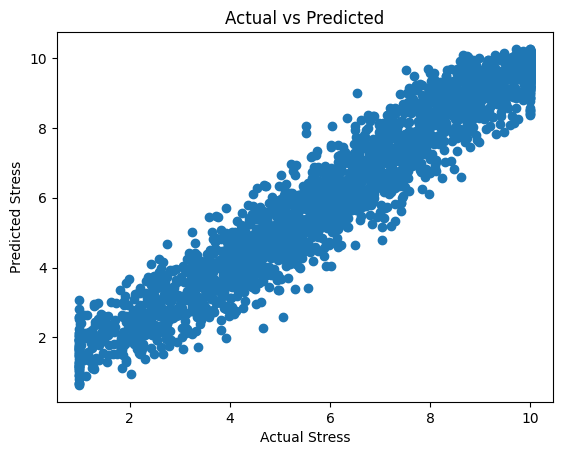

In [182]:
plt.scatter(y_test, y_pred1,)
plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")
plt.title("Actual vs Predicted")
plt.show()

In [184]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [186]:
svr_scores = cross_val_score(model1, x, y, cv=kf, scoring="r2")
print("SVR R2 scores:", svr_scores)
print("SVR Average R2:", np.mean(svr_scores))

SVR R2 scores: [0.94721134 0.95043748 0.94749965 0.9469191  0.94744726]
SVR Average R2: 0.947902966869621


In [187]:
dt_scores = cross_val_score(model2, x, y, cv=kf, scoring="r2")

print("Decision Tree R2 scores:", dt_scores)
print("Decision Tree Average R2:", np.mean(dt_scores))

Decision Tree R2 scores: [0.89615754 0.89777315 0.89644444 0.8934719  0.89948889]
Decision Tree Average R2: 0.8966671853756674


In [188]:
rf_scores = cross_val_score(model3, x, y, cv=kf, scoring="r2")

print("Random Forest R2 scores:", rf_scores)
print("Random Forest Average R2:", np.mean(rf_scores))

Random Forest R2 scores: [0.94712898 0.94926938 0.9471064  0.94576161 0.94768287]
Random Forest Average R2: 0.9473898479210447


In [194]:
import joblib

joblib.dump(model1, "stress_model.pkl")

['stress_model.pkl']

## Model Deployment

The trained model is deployed using Streamlit to create an interactive web application.

The application allows users to input lifestyle information and receive a predicted stress level in real time.

#  Conclusion

This project explored the relationship between **smartphone usage, sleep habits, and stress levels** using machine learning techniques.

Key findings include:

- Screen time and sleep quality strongly influence stress levels  
- Lifestyle behaviors significantly impact mental health  
- Machine learning models can effectively predict stress levels  

The trained model achieved strong predictive performance and was successfully deployed as a web application.